# 3 · Calibration, operating point, final model

**What this notebook establishes**

1. The operating threshold is **0.18**, chosen from an 80% recall target — not 0.5.
2. Raw probabilities need a base-rate correction before display; the deployed
   precision at that threshold is ~0.019, not 0.386.
3. Risk bands as multiples of the base rate separate cleanly: 12.5% → 81.4% fire rate.

---

A trained model is not yet a deployable one. Two things stand between a raw score and a
number a user can act on, and both are saved beside the model in `artifacts/`.

**The threshold.** The default 0.5 is wrong here — at 0.5 this model misses roughly four
fires in five. Fixing only the threshold took F1 from 0.282 to 0.50 with no change to the
model at all.

**The base-rate correction.** Training data is 1:3 by construction; real fire-days are
~1 in 100 eligible cell-days in season. Uncorrected probabilities are on the sampled
scale and make every location look alarming.

In [1]:
import sys, pathlib, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd()))
warnings.filterwarnings("ignore")

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib import import_module
setup = import_module("00_setup")

from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from firerisk.evaluation import TUNED_PARAMS, cross_validate

d = setup.load_dataset()
FEATURES = setup.FEATURES
X, y, years = d[FEATURES], d["label"], d["year"]

SAMPLED_RATE = float(y.mean())
REAL_RATE = int(y.sum()) / (d.cell_id.nunique() * 153 * d.year.nunique())
print(f"sampled {SAMPLED_RATE*100:.1f}%  ·  real {REAL_RATE*100:.2f}% "
      f"(1 in {1/REAL_RATE:.0f} cell-days)")

sampled 24.9%  ·  real 1.00% (1 in 100 cell-days)


## Out-of-fold predictions

Everything below is computed from **out-of-fold** probabilities — no row is scored by a
model that trained on its year. In-fold probabilities would make every number optimistic.

Same `cross_validate` as notebook 02, so the numbers here are comparable to the model
comparison rather than merely similar to it.

In [2]:
folds, oof = cross_validate(lgb.LGBMClassifier(**TUNED_PARAMS), X, y, years)
folds.round(4)

,pr_auc,roc_auc,precision,recall,f1,threshold
0,0.7144,0.8273,0.4619,0.8912,0.6084,0.18
1,0.5198,0.7864,0.3951,0.7090,0.5074,0.24
2,0.4896,0.7879,0.3901,0.7068,0.5027,0.26
3,0.6160,0.7948,0.4337,0.8118,0.5653,0.17
4,0.5537,0.7727,0.4311,0.7115,0.5369,0.20


## What each threshold buys

In [3]:
def deployed_precision(p, sampled_rate=SAMPLED_RATE, real_rate=REAL_RATE):
    # precision at the real base rate, not the sampled 1:3
    if p <= 0:
        return 0.0
    p = min(float(p), 1 - 1e-12)
    odds = p / (1 - p)
    shift = (real_rate / (1 - real_rate)) / (sampled_rate / (1 - sampled_rate))
    return (odds * shift) / (1 + odds * shift)

n_pos = int(y.sum())
rows = []
for t in [0.05, 0.10, 0.15, 0.18, 0.20, 0.25, 0.30, 0.40, 0.50, 0.70]:
    yhat = (oof >= t).astype(int)
    p = precision_score(y, yhat, zero_division=0)
    rows.append({"threshold": t, "precision": p,
                 "recall": recall_score(y, yhat, zero_division=0),
                 "f1": f1_score(y, yhat, zero_division=0),
                 "fires_missed": n_pos - int(((yhat == 1) & (y == 1)).sum()),
                 "false_alarms": int(((yhat == 1) & (y == 0)).sum()),
                 "deployed_precision": deployed_precision(p)})
pd.DataFrame(rows).round(4)

,threshold,precision,recall,f1,fires_missed,false_alarms,deployed_precision
0,0.05,0.2894,0.9811,0.4470,573,73106,0.0122
1,0.10,0.3279,0.9370,0.4858,1911,58289,0.0146
2,0.15,0.3688,0.8701,0.5180,3944,45193,0.0174
3,0.18,0.3946,0.8218,0.5332,5408,38265,0.0194
4,0.20,0.4125,0.7842,0.5406,6551,33901,0.0208
5,0.25,0.4588,0.6946,0.5526,9270,24868,0.0251
6,0.30,0.5023,0.6084,0.5503,11885,18295,0.0297
7,0.40,0.5868,0.4633,0.5178,16289,9900,0.0413
8,0.50,0.6628,0.3438,0.4528,19916,5308,0.0563
9,0.70,0.7899,0.1541,0.2579,25673,1244,0.1024


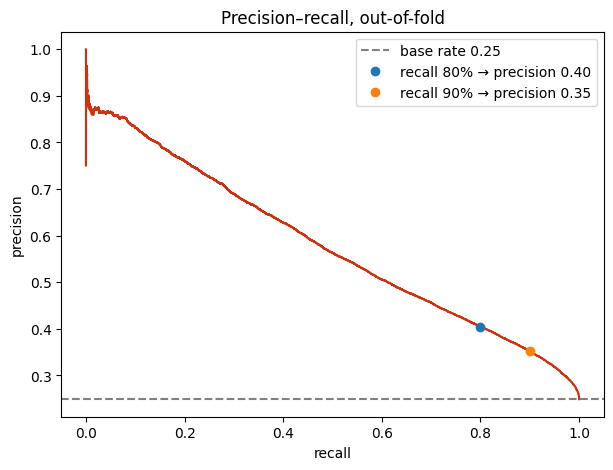

In [4]:
prec, rec, thr = precision_recall_curve(y, oof)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="#cc3311")
ax.axhline(SAMPLED_RATE, ls="--", c="grey", label=f"base rate {SAMPLED_RATE:.2f}")
for target in (0.80, 0.90):
    i = np.argmin(np.abs(rec - target))
    ax.plot(rec[i], prec[i], "o", label=f"recall {target:.0%} → precision {prec[i]:.2f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision–recall, out-of-fold"); ax.legend()

## Choosing the operating point

F1 weights a missed fire and a false alarm equally. For fire risk they are not equal, so
the threshold should come from a stated **recall target** instead.

Note how cheap recall is here: going from ~73% to ~95% recall costs far less precision
than the equal-weight optimum implies.

In [5]:
def threshold_for_recall(target):
    # most strict cutoff that still catches `target` of the fires
    ok = [t for t in np.linspace(0.01, 0.99, 99)
          if recall_score(y, (oof >= t).astype(int), zero_division=0) >= target]
    return float(max(ok)) if ok else 0.01

targets = pd.DataFrame([
    {"target_recall": t,
     "threshold": threshold_for_recall(t),
     "precision": precision_score(y, (oof >= threshold_for_recall(t)).astype(int),
                                  zero_division=0)}
    for t in (0.70, 0.80, 0.90, 0.95)
]).round(3)

TARGET_RECALL = 0.80
THRESHOLD = threshold_for_recall(TARGET_RECALL)
print(f"chosen: {THRESHOLD:.2f} for {TARGET_RECALL:.0%} recall")
targets

chosen: 0.19 for 80% recall


,target_recall,threshold,precision
0,0.70,0.24,0.449
1,0.80,0.19,0.403
2,0.90,0.12,0.344
3,0.95,0.08,0.312


## Risk bands, not a yes/no alarm

Fire agencies publish danger ratings, not binary alarms — and a threshold throws away
information the app could show.

Bands are expressed as **multiples of the base rate**. Absolute cutoffs fail: corrected
probabilities compress into roughly 0–0.11, so a rule like "Extreme > 0.5" would never
trigger once.

In [6]:
def correct_base_rate(proba, sampled_rate=SAMPLED_RATE, real_rate=REAL_RATE):
    proba = np.clip(np.asarray(proba, float), 1e-9, 1 - 1e-9)
    odds = proba / (1 - proba)
    shift = (real_rate / (1 - real_rate)) / (sampled_rate / (1 - sampled_rate))
    adj = odds * shift
    return adj / (1 + adj)

RISK_MULTIPLES = [(0, 1, "Low"), (1, 3, "Moderate"), (3, 8, "High"), (8, np.inf, "Extreme")]

def risk_band(p, real_rate=REAL_RATE):
    ratio = float(p) / real_rate
    for lo, hi, label in RISK_MULTIPLES:
        if lo <= ratio < hi:
            return label
    return "Extreme"

adj = correct_base_rate(oof)
bands = pd.Series([risk_band(v) for v in adj], index=d.index)
order = ["Low", "Moderate", "High", "Extreme"]
tab = pd.crosstab(bands, y).reindex(order).fillna(0).astype(int)
tab.columns = ["no fire", "fire"]
tab["fire rate"] = (tab["fire"] / tab.sum(axis=1) * 100).round(1)
print(f"raw mean {oof.mean():.3f} → corrected mean {adj.mean():.4f}")
tab

raw mean 0.244 → corrected mean 0.0160


,no fire,fire,fire rate
row_0,,,
Low,66504,9218,12.2
Moderate,19847,10834,35.3
High,4342,6656,60.5
Extreme,825,3643,81.5


Fire rate must rise monotonically across the bands — that is what makes them meaningful
to show a user.

## Fit on everything and save

The artifact carries the model **and** the threshold **and** the base-rate constants. A
`.joblib` alone would let the API silently fall back to 0.5 — the exact failure this
project started with.

In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score

final = lgb.LGBMClassifier(**TUNED_PARAMS).fit(X, y)
art = setup.ROOT / "artifacts"
art.mkdir(exist_ok=True)
joblib.dump({"model": final, "features": FEATURES}, art / "model.joblib")

yhat = (oof >= THRESHOLD).astype(int)
meta = {
    "features": FEATURES,
    "n_rows": int(len(d)),
    "years": [int(years.min()), int(years.max())],
    "sampled_base_rate": SAMPLED_RATE,
    "real_base_rate": REAL_RATE,
    "threshold": THRESHOLD,
    "target_recall": TARGET_RECALL,
    "risk_multiples": [[lo, None if np.isinf(hi) else hi, n] for lo, hi, n in RISK_MULTIPLES],
    "oof_pr_auc": float(average_precision_score(y, oof)),
    "oof_roc_auc": float(roc_auc_score(y, oof)),
    "at_operating_point": {
        "precision": float(precision_score(y, yhat, zero_division=0)),
        "recall": float(recall_score(y, yhat, zero_division=0)),
        "f1": float(f1_score(y, yhat, zero_division=0)),
    },
    "params": TUNED_PARAMS,
    "protocol": ("5-fold CV grouped by year; threshold from a recall target on "
                 "out-of-fold predictions; probabilities require base-rate "
                 "correction before display"),
}
(art / "metrics.json").write_text(json.dumps(meta, indent=2))
print(json.dumps({k: meta[k] for k in
                  ["threshold", "target_recall", "oof_pr_auc", "at_operating_point"]},
                 indent=2))

{
  "threshold": 0.19,
  "target_recall": 0.8,
  "oof_pr_auc": 0.5775344548477807,
  "at_operating_point": {
    "precision": 0.40296136984035075,
    "recall": 0.8025106256795492,
    "f1": 0.5365214326622318
  }
}
